In [5]:
import numpy as np
import tifffile as tiff
import h5py
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import scipy.ndimage as ndi
from tqdm.notebook import tqdm
from scipy.interpolate import make_interp_spline, make_lsq_spline
import cv2


# def overlay(bck, top, thr=0.2, ax=None):
#     bck_ = bck
#     if bck.shape[0] < top.shape[0]:
#         bck_ = cv2.resize(bck, top.shape)
    
#     v1 = np.quantile(top, 0.99)
#     v2 = np.quantile(top, 0.01)
#     ima_scaled = np.clip((top - v2)/(v1-v2), 0, 1)
#     ima_mapped = mpl.colormaps.get('plasma')(ima_scaled)
#     imb_mapped = mpl.colormaps.get('bone')(bck_/np.max(bck_))
#     mask = ima_scaled > thr

#     im_comb = np.copy(imb_mapped)
#     im_comb[mask] = imb_mapped[mask]*0.1 + 0.9*ima_mapped[mask]

#     if ax is None:
#         return plt.imshow(im_comb)
#     else:
#         return ax.imshow(im_comb)

In [9]:
#https://www.linkedin.com/pulse/splines-python-feature-selection-data-smoothing-robert-prior
def knot_points(nKnots, x, degree):
    knots = np.linspace(x[0], x[-1], nKnots) #create the knot locations
    lo = min(x[0], knots[0]) #we have to add these min and values to conform by adding preceding and proceeding values
    hi = max(x[-1], knots[-1])
    augmented_knots = np.append(np.append([lo]*degree, knots), [hi]*degree)
    return augmented_knots

my_drifts = np.load('cnn_detected_drift2.npy')

my_drift_frm = np.arange(my_drifts.shape[0])*50 + 0

iframes = np.arange(2000)
knots = knot_points(5, iframes, 3)
smoothened_x = make_lsq_spline(my_drift_frm, my_drifts[:,0], t=knots)(iframes)
smoothened_y = make_lsq_spline(my_drift_frm, my_drifts[:,1], t=knots)(iframes)

dcols = "id","frame","x [nm]","y [nm]","sigma [nm]","intensity [photon]","offset [photon]","bkgstd [photon]"
thst_drift = np.genfromtxt('thst_drifts.csv',skip_header=1, delimiter=',')

thst_dx = np.interp(np.arange(2000), thst_drift[:,4]-1, thst_drift[:,5])
thst_dy = np.interp(np.arange(2000), thst_drift[:,6]-1, thst_drift[:,7])


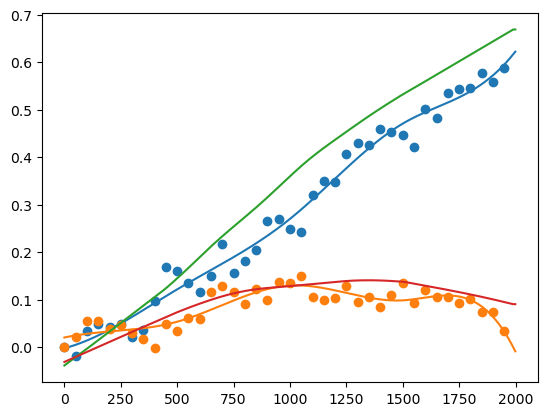

In [10]:
plt.plot(my_drift_frm, my_drifts[:,0]/4, "C0o")
plt.plot(iframes, smoothened_x/4, "C0-")
plt.plot(my_drift_frm, my_drifts[:,1]/4, "C1o")
plt.plot(iframes, smoothened_y/4, "C1-")

plt.plot(iframes, thst_dx, "C2-")
plt.plot(iframes, thst_dy, "C3-")


In [11]:
# decode_image = generate_decode_image(d_emitters, 512*4, 512*4, upscale_and_round_to_grid, thst_dx, thst_dy)

In [26]:
BLUR = 1
Q = 0.001
def representation(img, blur=BLUR, gamma=0.8, quantile=Q):
    blurred = ndi.gaussian_filter(img, blur)
    normed = (blurred - np.min(blurred)).astype(np.float32)
    normed /= np.max(normed)    
    rescaled = normed**0.8
    qlo = np.quantile(rescaled, quantile)
    qhi = np.quantile(rescaled, 1-quantile)
    return rescaled, qlo, qhi


In [27]:
process_images = np.load('render_outputs_bio_cnn_decode_thst_dc.npz')
storm_image_all=process_images['thst']
decode_image = process_images['decode']
cnn_out = process_images['cnn']
imgmx = process_images['rawmax']
imgsum = process_images['rawsum']

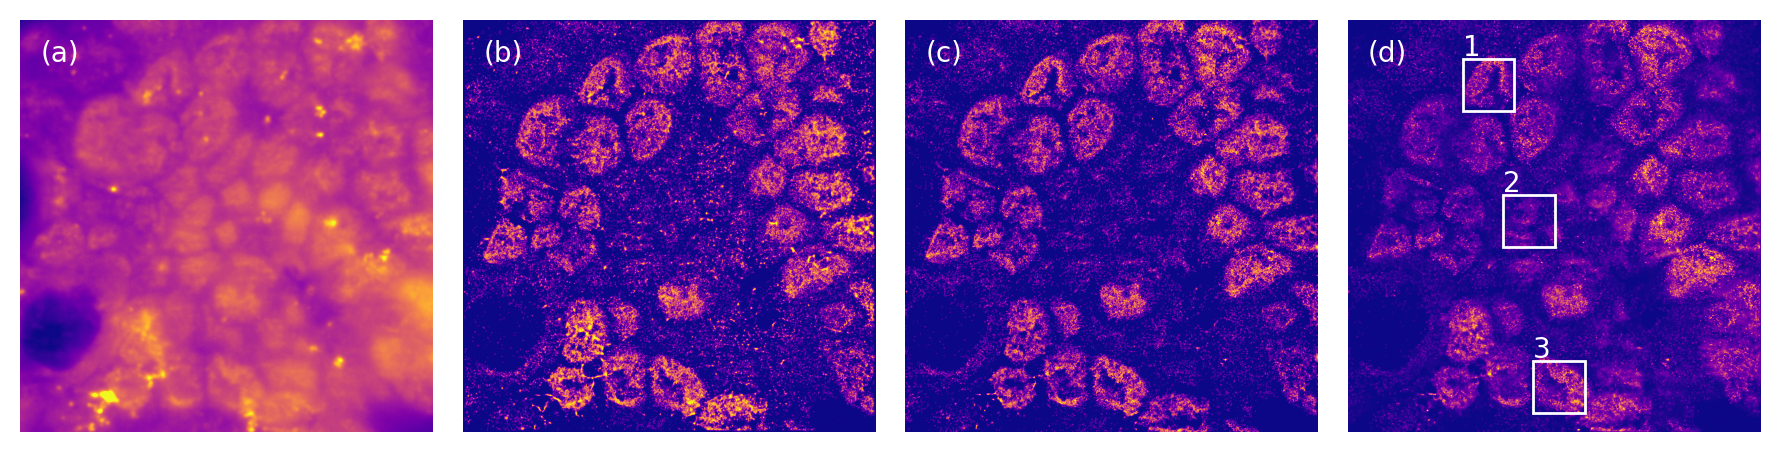

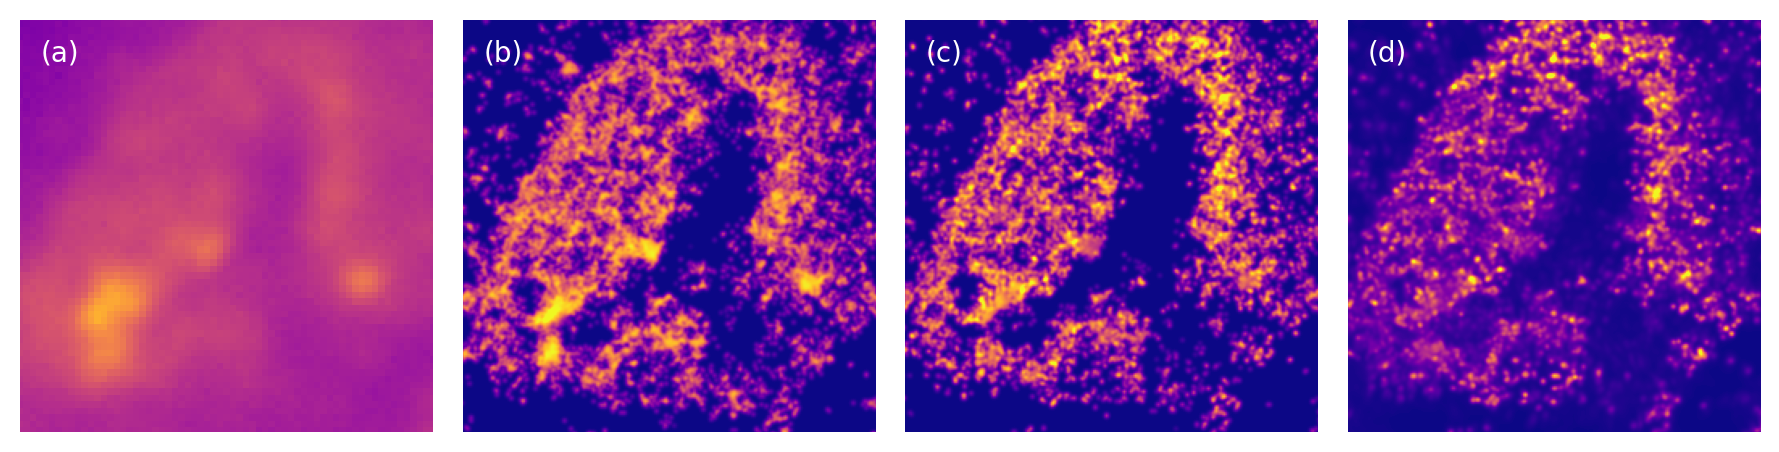

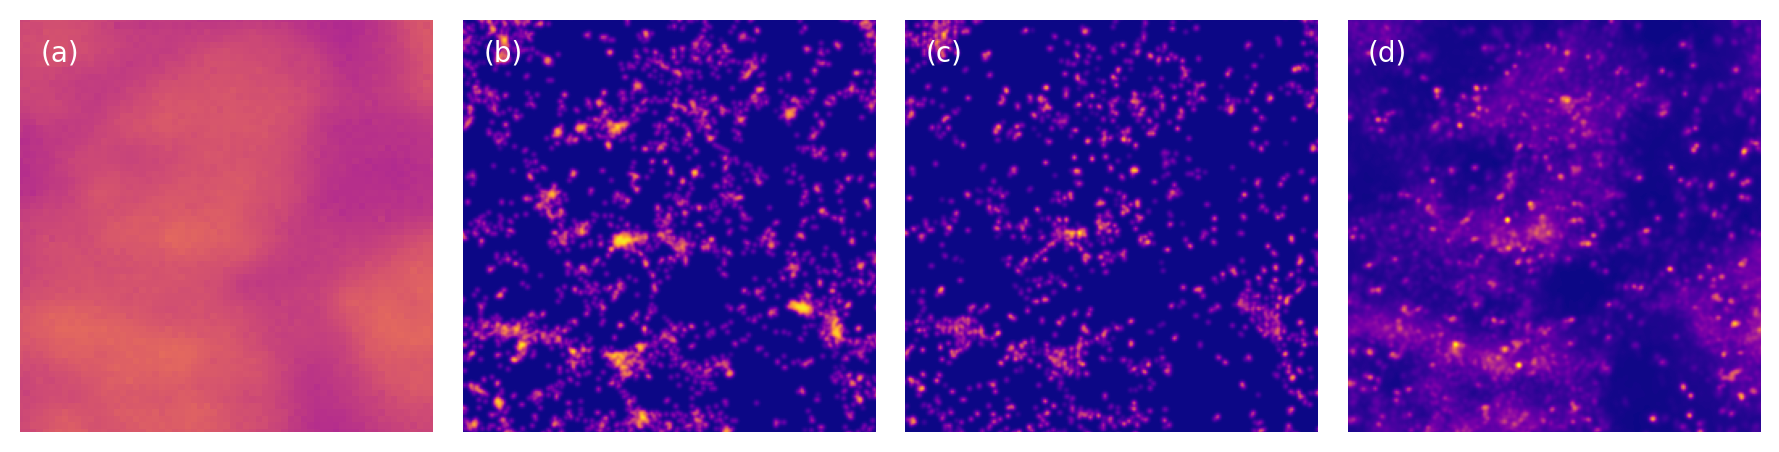

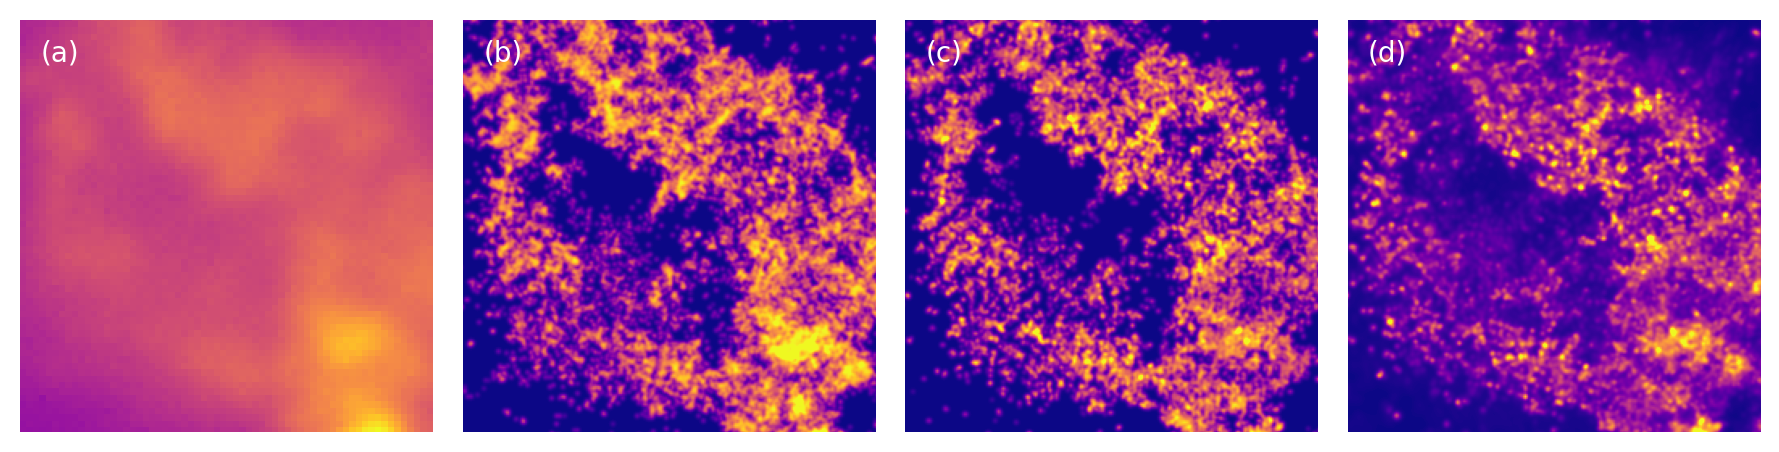

In [28]:
%matplotlib inline
# rois = [(325, 700),(1025, 950),(1825, 1050)] #in super-resolved pixels
rois = [(325, 700),(1000, 900),(1825, 1050)] #in super-resolved pixels
cm = 'plasma'
to_plot = (imgsum, storm_image_all, decode_image, cnn_out)
fig, ax = plt.subplots(1,4, figsize=(9,3), dpi=200)
for axi, label, im in zip(ax, 'abcd', to_plot):
    axi.set_axis_off()
    axi.text(0.05, 0.9, f'({label})', color='w', transform=axi.transAxes)
    if label != 'a':
        _im, _vmnm, _vmxm = representation(im, BLUR, 0.8, 1e-3)
        axi.imshow(_im, cmap=cm, vmin=_vmnm, vmax=_vmxm)
    else:
        _im, _vmnm, _vmxm = representation(im, 0, 0.8, 1e-3)
        axi.imshow(_im, cmap=cm, vmin=_vmnm, vmax=_vmxm)

span = 128        
for _i, (_row, _col) in enumerate(rois):
    rect = Rectangle((_col-span, _row-span), span*2, span*2,
                        edgecolor='white', facecolor='none', linewidth=1)
    ax[-1].add_patch(rect)
    ax[-1].annotate(f'{_i+1:d}', (_col-span + 0, _row-span - 20), color='white') 
plt.tight_layout()
plt.show()


for _row, _col in rois:

    fig, ax = plt.subplots(1,4, figsize=(9,3), dpi=200)
    for axi, label, im in zip(ax, 'abcd', to_plot):
        axi.set_axis_off()
        axi.text(0.05, 0.9, f'({label})', color='w', transform=axi.transAxes)
        if label != 'a':
            _im, _vmnm, _vmxm = representation(im, BLUR, 0.8, 1e-3)
            axi.imshow(_im, cmap=cm, vmin=_vmnm, vmax=_vmxm)
            axi.set_xlim(_col - span, _col + span)
            axi.set_ylim(_row + span, _row - span)
        else:
            _im, _vmnm, _vmxm = representation(im, 0, 0.8, 1e-3)
            axi.imshow(_im, cmap=cm, vmin=_vmnm, vmax=_vmxm)
            axi.set_ylim(_row/4 + span/4, _row/4 - span/4)
            axi.set_xlim(_col/4 - span/4, _col/4 + span/4)
    plt.tight_layout()
    plt.show()

https://www.science.org/doi/10.1126/sciadv.aaw0683

H4Ac labeled with Alexa Fluor 647 in a mouse intestinal tissue section.
see fig. 6